<a href="https://colab.research.google.com/github/oliverclaypole/7BUIS010W/blob/main/Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

#  A.1: Extract S&P 500 tickers from Wikipedia

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
# Adding headers mimics a real browser request, avoiding Wikipedia's 403 block

tables = pd.read_html(url, storage_options=headers)
SP500_tickers = tables[0]
print("S&P 500 table loaded:")
print(SP500_tickers.head())
print(f"Total companies in table: {len(SP500_tickers)}")

# Build ticker list — replace '.' with '-' for Yahoo Finance compatibility
# e.g. BRK.B → BRK-B
ticker_list = [t.replace('.', '-') for t in SP500_tickers['Symbol'].tolist()]
print(f"\nTotal tickers extracted: {len(ticker_list)}")
print(f"Sample tickers: {ticker_list[:10]}")

S&P 500 table loaded:
  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  
Total companies in table: 503

Tot

In [3]:
#  A.2: Download daily price data using yfinance
START_DATE = '2022-01-01'
END_DATE   = '2025-01-01'

print("Downloading S&P 500 price data (this takes 2–4 minutes)...")

stock_data = yf.download(
    ticker_list,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,   # adjusted prices returned under 'Close'
    progress=True
)

stock_prices = stock_data['Close'].copy()

print(f"\nRaw download shape: {stock_prices.shape}")
print(f"Missing values before cleaning: {stock_prices.isna().sum().sum():,}")

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')



Raw download shape: (753, 503)
Missing values before cleaning: 3,651


In [4]:
#  A.3: Identify and remove invalid data
total_days = stock_prices.shape[0]
missing_per_ticker = stock_prices.isna().sum()

# Identify tickers that are missing more than 5% of all trading days
# (these are typically stocks added to the index after Jan 2022)
threshold = 0.05 * total_days
tickers_to_drop = missing_per_ticker[missing_per_ticker > threshold].index.tolist()

print(f"Trading days in dataset  : {total_days}")
print(f"Tickers before cleaning  : {stock_prices.shape[1]}")
print(f"Tickers dropped (>5% NaN): {len(tickers_to_drop)}")
print(f"Dropped: {tickers_to_drop}")

# Drop the heavily incomplete tickers
stock_prices_clean = stock_prices.drop(columns=tickers_to_drop)

# Forward-fill then back-fill any isolated remaining NaNs
stock_prices_clean = stock_prices_clean.ffill().bfill()

print(f"\nTickers after cleaning   : {stock_prices_clean.shape[1]}")
print(f"Remaining NaN values     : {stock_prices_clean.isna().sum().sum()}")
print(f"Final shape              : {stock_prices_clean.shape}")
stock_prices_clean.head()


Trading days in dataset  : 753
Tickers before cleaning  : 503
Tickers dropped (>5% NaN): 7
Dropped: ['GEHC', 'GEV', 'KVUE', 'Q', 'SNDK', 'SOLV', 'VLTO']

Tickers after cleaning   : 496
Remaining NaN values     : 0
Final shape              : (753, 496)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103668,114.894028,172.679993,127.545822,42.362530,380.485199,564.369995,164.526474,60.037262,...,33.979382,85.125786,59.164787,54.760239,110.957481,164.029999,125.887230,120.797707,583.900024,224.021255
2022-01-04,146.573715,175.843231,114.673447,170.800003,124.546120,42.914051,377.766266,554.000000,163.040497,61.151539,...,34.414902,84.854202,59.539253,56.819992,112.134552,156.330002,126.560318,122.023193,587.599976,215.492279
2022-01-05,144.062759,171.165817,115.275818,162.250000,123.986572,42.410072,371.113617,514.429993,160.523605,60.673985,...,33.560612,81.711830,60.122711,57.526676,110.606270,143.490005,124.955963,121.620941,558.179993,207.298355
2022-01-06,144.566895,168.308502,114.732834,159.750000,123.968201,42.657307,353.192322,514.119995,161.034393,61.213425,...,33.828621,82.090073,59.652462,58.879749,110.454369,144.660004,126.246796,120.610619,555.159973,208.121597
2022-01-07,140.718048,168.474823,114.435898,166.050003,124.353493,42.856995,346.418121,510.700012,156.808624,61.735184,...,33.786751,82.002785,60.174965,59.362366,109.571579,141.539993,124.799202,119.880959,530.859985,202.062317


In [5]:
#  A.4: Calculate Daily Returns
# Formula: Daily Return = (Price_today - Price_yesterday) / Price_yesterday
# This is equivalent to pandas .pct_change()

daily_returns = stock_prices_clean.pct_change()
daily_returns.dropna(how='all', inplace=True)  # drop first row (no previous day)

print(f"Daily Returns shape: {daily_returns.shape}")
print(f"\nSample (first 5 rows, first 5 tickers):")
print(daily_returns.iloc[:5, :5].round(6))
print(f"\nAverage daily return across all stocks: {daily_returns.mean().mean()*100:.4f}%")

Daily Returns shape: (752, 496)

Sample (first 5 rows, first 5 tickers):
Ticker             A      AAPL      ABBV      ABNB       ABT
Date                                                        
2022-01-04 -0.033806 -0.012692 -0.001920 -0.010887 -0.023519
2022-01-05 -0.017131 -0.026600  0.005253 -0.050059 -0.004493
2022-01-06  0.003499 -0.016693 -0.004710 -0.015408 -0.000148
2022-01-07 -0.026623  0.000988 -0.002588  0.039437  0.003108
2022-01-10  0.000069  0.000116  0.011195 -0.032159 -0.002213

Average daily return across all stocks: 0.0441%


In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# A.5: Calculate Beta
# Formula: Beta = corr(stock_returns, index_returns) × (std_stock / std_index)
# Benchmark: S&P 500 index (^GSPC)

index_raw     = yf.download('^GSPC', start='2022-01-01', end='2025-01-01',
                             auto_adjust=True, progress=False)
index_returns = index_raw['Close'].pct_change().dropna()
# FIX: Ensure index_std is a scalar by selecting the value from the Series
index_std     = index_returns['^GSPC'].std()

# Align stock returns with index returns on matching dates
aligned_stocks, aligned_index = daily_returns.align(
    index_returns, join='inner', axis=0
)

beta_dict = {}
for ticker in aligned_stocks.columns:
    s = aligned_stocks[ticker].dropna()
    # FIX: Ensure 'm' is a Series by explicitly selecting the '^GSPC' column
    m = aligned_index.loc[s.index, '^GSPC']
    if len(s) < 30:
        continue
    corr = s.corr(m)
    beta_dict[ticker] = round(corr * (s.std() / index_std), 4)

beta_series = pd.Series(beta_dict, name='Beta').sort_values(ascending=False)

print(f"Beta calculated for {len(beta_series)} stocks")
print(f"\nBeta summary:")
print(beta_series.describe().round(4))
print(f"\nTop 5 highest beta: \n{beta_series.head()}")
print(f"\nTop 5 lowest beta: \n{beta_series.tail()}")

Beta calculated for 496 stocks

Beta summary:
count    496.0000
mean       0.9437
std        0.4318
min        0.1332
25%        0.6330
50%        0.9117
75%        1.1557
max        3.2941
Name: Beta, dtype: float64

Top 5 highest beta: 
CVNA    3.2941
COIN    2.9610
XYZ     2.5448
NVDA    2.2685
APP     2.2619
Name: Beta, dtype: float64

Top 5 lowest beta: 
LMT    0.2439
HRL    0.2366
SJM    0.1966
CPB    0.1337
GIS    0.1332
Name: Beta, dtype: float64


In [7]:
# A.6: Calculate Annual Volatility
# Formula: Annual Volatility = Daily Return Std Dev × √252
# 252 = standard number of trading days in a year

annual_vol = (daily_returns.std() * np.sqrt(252) * 100).round(4)
annual_vol.name = 'Annual_Volatility_Pct'

print(f"Annual Volatility calculated for {len(annual_vol)} stocks")
print(f"\nVolatility summary (%):")
print(annual_vol.describe().round(4))
print(f"\nMost volatile stocks:")
print(annual_vol.sort_values(ascending=False).head())
print(f"\nLeast volatile stocks:")
print(annual_vol.sort_values().head())

Annual Volatility calculated for 496 stocks

Volatility summary (%):
count    496.0000
mean      31.4300
std       11.4803
min       15.6193
25%       24.0116
50%       28.5016
75%       35.7327
max      134.1039
Name: Annual_Volatility_Pct, dtype: float64

Most volatile stocks:
Ticker
CVNA    134.1039
COIN     95.3848
SMCI     90.1957
APP      78.8374
PLTR     69.0932
Name: Annual_Volatility_Pct, dtype: float64

Least volatile stocks:
Ticker
KO     15.6193
JNJ    16.3759
PEP    17.0398
MCD    17.3512
CL     17.3713
Name: Annual_Volatility_Pct, dtype: float64


In [8]:
#Consolidate all metrics into one DataFrame

mean_return = (daily_returns.mean() * 100).round(6)
mean_return.name = 'Mean_Daily_Return_Pct'

sector_map = SP500_tickers.set_index(
    SP500_tickers['Symbol'].str.replace('.', '-', regex=False)
)['GICS Sector'].to_dict()

metrics_df = pd.DataFrame({
    'Mean_Daily_Return_Pct' : mean_return,
    'Beta'                  : beta_series,
    'Annual_Volatility_Pct' : annual_vol
})
metrics_df['Sector'] = metrics_df.index.map(sector_map)
metrics_df.dropna(inplace=True)
metrics_df.index.name = 'Ticker'

print(f"Master metrics DataFrame: {metrics_df.shape}")
print(metrics_df.head(10))

# Save for Task B
metrics_df.to_csv('sp500_metrics.csv')
print("\nSaved: sp500_metrics.csv")

Master metrics DataFrame: (496, 4)
        Mean_Daily_Return_Pct    Beta  Annual_Volatility_Pct  \
Ticker                                                         
A                   -0.000158  1.0248                29.6259   
AAPL                 0.059113  1.2107                27.0935   
ABBV                 0.060992  0.2991                21.9958   
ABNB                 0.007361  1.6663                46.7875   
ABT                 -0.010575  0.6723                21.7839   
ACGL                 0.116465  0.5698                25.3997   
ACN                  0.001063  1.0942                27.0331   
ADBE                -0.002166  1.4480                38.3083   
ADI                  0.051419  1.3399                31.8058   
ADM                 -0.011053  0.5512                29.4043   

                        Sector  
Ticker                          
A                  Health Care  
AAPL    Information Technology  
ABBV               Health Care  
ABNB    Consumer Discretionary 

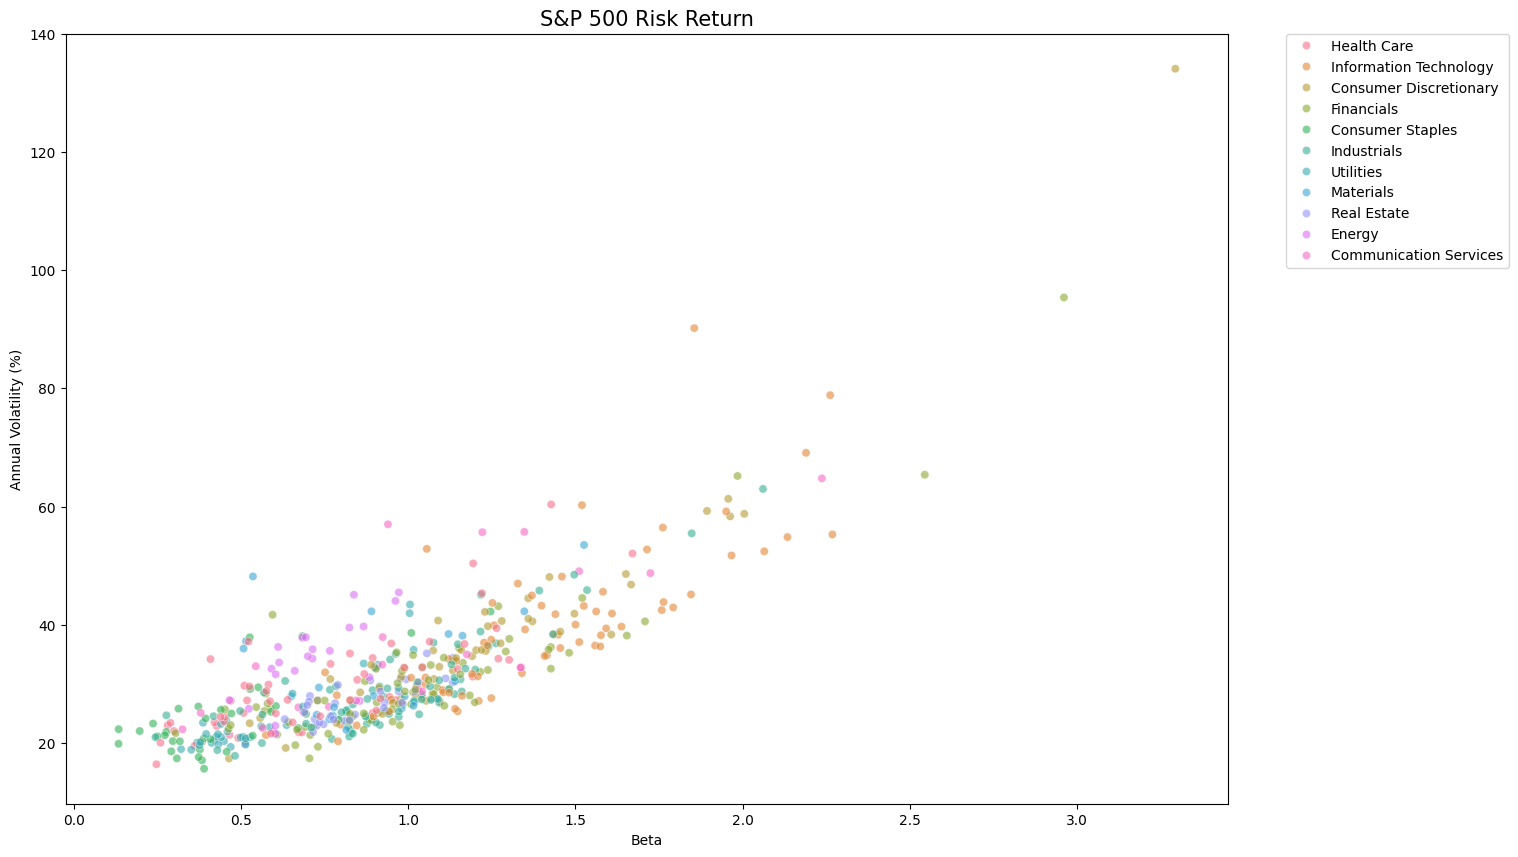

In [9]:
# A.7
# Plots

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))    # creating dimensions

sns.scatterplot(
    data=metrics_df,            # tells the plot where to pull info from
    x='Beta',                   # assigning beta to x axis
    y='Annual_Volatility_Pct',  # assigning annual volatility to y axis
    hue='Sector',               # colour assigns based on sector
    alpha=0.6                   # sets the transparency of the dots
)


plt.title('S&P 500 Risk Return', fontsize=15)                    # plots title
plt.xlabel('Beta')                                               # plots x-axis
plt.ylabel('Annual Volatility (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

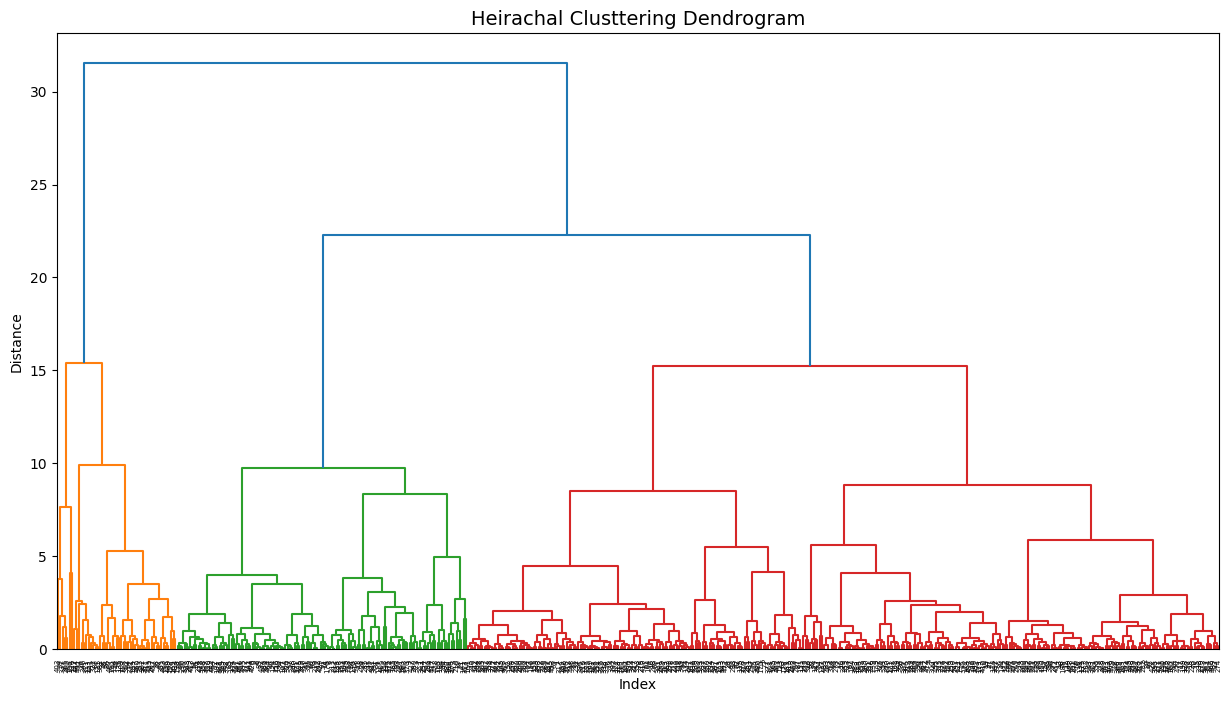

In [11]:
# B.1

import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# scaling the data so beta is not ignored
scaler = StandardScaler()
X_Scaled_Data = scaler.fit_transform(metrics_df[['Mean_Daily_Return_Pct', 'Beta', 'Annual_Volatility_Pct']])

# creates dendriogram
plt.figure(figsize=(15, 8))
linkage_data = sch.linkage(X_Scaled_Data, method='ward')
dendrogram = sch.dendrogram(linkage_data)

plt.title('Heirachal Clusttering Dendrogram', fontsize=14)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show

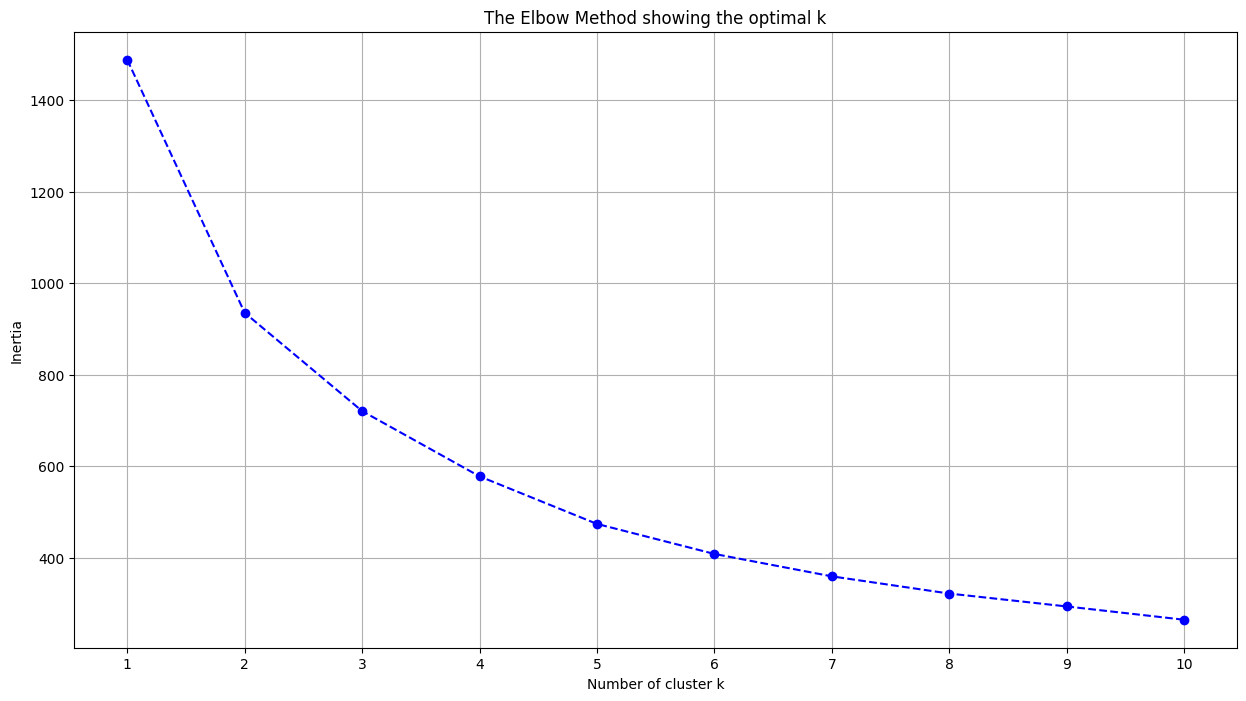

In [15]:
# B.2
# K - means Clustering

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# calculating inertia (sum of squared distances to the closest cluster centre)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_Scaled_Data)
    inertia.append(kmeans.inertia_)

# Plot the elbow graph

plt.figure(figsize=(15, 8))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method showing the optimal k')
plt.xlabel('Number of cluster k')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

final_model = KMeans(n_clusters=3, random_state=42, n_init=10)
metrics_df['Cluster'] = final_model.fit(X_Scaled_Data)